In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import json
import os

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [ ]:
TRAIN_DIR = "../dataset/train"
VALID_DIR = "../dataset/valid"

MODEL_PATH = "../models/trained_plant_disease_model.keras"
HISTORY_PATH = "../models/training_history.json"

IMG_SIZE = (128,128)
BATCH_SIZE = 32
EPOCHS = 10

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

Found 70295 files belonging to 38 classes.


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 17572 files belonging to 38 classes.


In [5]:
class_names = train_ds.class_names

print("Total Classes:", len(class_names))
print(class_names[:5])

Total Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [11]:
cnn = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(128,128,3)),

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(
        32,3,
        padding='same',
        activation='relu'
    ),

    tf.keras.layers.Conv2D(
        32,3,
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,3,
        padding='same',
        activation='relu'
    ),

    tf.keras.layers.Conv2D(
        64,3,
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,3,
        padding='same',
        activation='relu'
    ),

    tf.keras.layers.Conv2D(
        128,3,
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        1024,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

In [12]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [13]:
cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │    25,691,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        38,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,017,094 (99.25 MB)

 Trainable params: 26,017,094 (99.25 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

In [15]:
history = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1786s 811ms/step - accuracy: 0.5583 - loss: 1.5041 - val_accuracy: 0.6306 - val_loss: 1.2536 - learning_rate: 1.0000e-04
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1424s 648ms/step - accuracy: 0.7863 - loss: 0.6895 - val_accuracy: 0.7597 - val_loss: 0.7747 - learning_rate: 1.0000e-04
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1441s 656ms/step - accuracy: 0.8502 - loss: 0.4719 - val_accuracy: 0.8419 - val_loss: 0.5100 - learning_rate: 1.0000e-04
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1387s 631ms/step - accuracy: 0.8865 - loss: 0.3528 - val_accuracy: 0.8903 - val_loss: 0.3318 - learning_rate: 1.0000e-04
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1449s 660ms/step - accuracy: 0.9085 - loss: 0.2801 - val_accuracy: 0.9102 - val_loss: 0.2771 - learning_rate: 1.0000e-04
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1460s 664ms/step - accuracy: 0.9228 - loss: 0.2347 - val_accuracy: 0.9117 - val_loss: 0.2787 - learning_rate: 1.0000e-04
Epoch 7/10
2197/2197 ━

In [16]:
train_loss, train_acc = cnn.evaluate(train_ds)

val_loss, val_acc = cnn.evaluate(val_ds)

print(f"Training Accuracy: {train_acc:.4f}")

print(f"Validation Accuracy: {val_acc:.4f}")

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 242s 110ms/step - accuracy: 0.9517 - loss: 0.1474
550/550 ━━━━━━━━━━━━━━━━━━━━ 59s 108ms/step - accuracy: 0.9393 - loss: 0.1928
Training Accuracy: 0.9517
Validation Accuracy: 0.9393


In [19]:
cnn.save(MODEL_PATH)

print("Model Saved")

Model Saved


In [20]:
with open(
    HISTORY_PATH,
    "w"
) as f:

    json.dump(
        history.history,
        f
    )

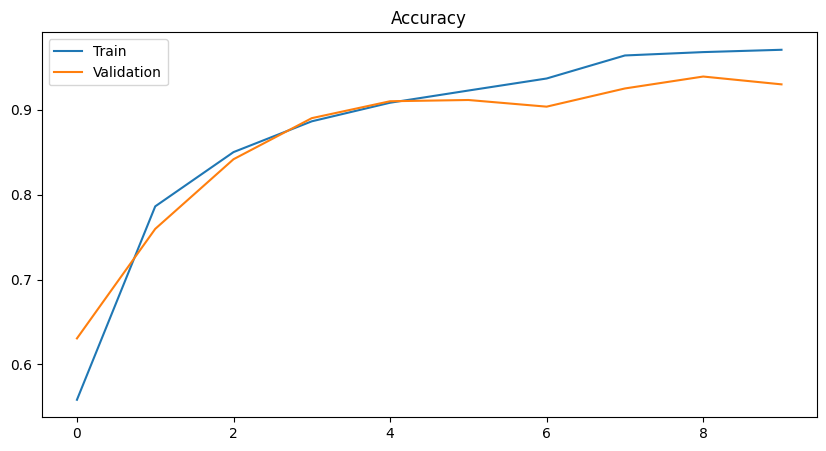

In [21]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Train'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation'
)

plt.title("Accuracy")

plt.legend()

plt.show()

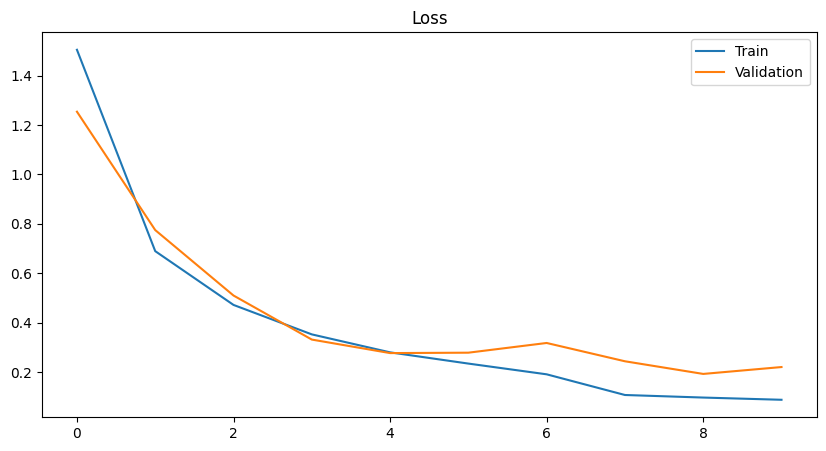

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train'
)

plt.plot(
    history.history['val_loss'],
    label='Validation'
)

plt.title("Loss")

plt.legend()

plt.show()